# 🏀 NBA Shot Analysis — Étape 1 : Exploration des données & DataViz

## 1. Contexte & périmètre métier

Chaque ligne correspond à **une tentative de tir** enregistrée par les tables de marque
officielles de la NBA (source : *sportsdataverse / ESPN NBA shots*). Le jeu couvre
**22 saisons régulières**, de **2003‑04 (`NBA_2004`) à 2024‑25 (`NBA_2025`)**.

> ⚠️ Convention de nommage : le fichier `NBA_YYYY` correspond à la saison **`YYYY-1 / YYYY`**
> (`SEASON_1 = 2004` ↔ `SEASON_2 = "2003-04"`).

### Notions métier utiles

| Terme | Définition |
|---|---|
| **FG% (Field Goal %)** | tirs réussis / tirs tentés (hors lancers francs) |
| **2PT / 3PT** | tir à 2 pts (intérieur de la ligne) / 3 pts (au-delà : 6,75 m en coin, 7,24 m ailleurs) |
| **Restricted Area** | demi-cercle sous le panier (~1,25 m) — zone de plus haute efficacité |
| **Mid-range** | tir à mi-distance (entre la raquette et la ligne à 3 pts) — zone la moins rentable |
| **Corner 3** | 3 pts pris dans le coin (ligne plus proche → meilleur pourcentage) |
| **Points par tir (PPA)** | espérance de points d'un tir = `FG% × valeur du tir` |
| **Clutch time** | 5 dernières minutes du 4e QT ou prolongation |

### Problématique de modélisation visée (étapes suivantes)

Prédire la **probabilité de réussite d'un tir** (`SHOT_MADE`) à partir de son contexte :
position sur le terrain, distance, type d'action, moment du match, profil du tireur.

## 2. Setup

On interroge directement les 22 CSV (~850 Mo) avec **DuckDB**, sans tout charger en mémoire
(`data/*.csv`, `union_by_name`). Pandas / Matplotlib / SciPy pour les visualisations et
les tests statistiques.

In [25]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA = "data/*.csv"
_SRC = f'read_csv_auto("{DATA}", union_by_name=true)'
con = duckdb.connect()

def q(sql):
    # remplace le jeton {DATA} par la lecture des 22 fichiers
    return con.execute(sql.replace("{DATA}", _SRC)).df()

## 3. Structure générale du jeu de données

In [12]:
overview = q('''
    SELECT
        COUNT(*)                  AS n_tirs,
        COUNT(DISTINCT SEASON_1)  AS n_saisons,
        COUNT(DISTINCT GAME_ID)   AS n_matchs,
        COUNT(DISTINCT PLAYER_ID) AS n_joueurs,
        COUNT(DISTINCT TEAM_ID)   AS n_equipes
    FROM {DATA}
''')
overview

,n_tirs,n_saisons,n_matchs,n_joueurs,n_equipes
0,4450789,22,26453,2265,30


In [3]:
schema = q("DESCRIBE SELECT * FROM {DATA}")
schema[["column_name", "column_type"]]

,column_name,column_type
0,SEASON_1,BIGINT
1,SEASON_2,VARCHAR
2,TEAM_ID,BIGINT
3,TEAM_NAME,VARCHAR
4,PLAYER_ID,BIGINT
5,PLAYER_NAME,VARCHAR
6,POSITION_GROUP,VARCHAR
7,POSITION,VARCHAR
8,GAME_DATE,VARCHAR
9,GAME_ID,BIGINT


In [4]:
q("SELECT * FROM {DATA} USING SAMPLE 5 ROWS")

,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,HOME_TEAM,AWAY_TEAM,EVENT_TYPE,SHOT_MADE,ACTION_TYPE,SHOT_TYPE,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
0,2004,2003-04,1610612754,Indiana Pacers,1902,Jeff Foster,C,C,04-14-2004,20301181,IND,CHI,Missed Shot,False,Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.55,0,3,7,45
1,2004,2003-04,1610612747,Los Angeles Lakers,2416,Kareem Rush,G,SG,04-09-2004,20301145,LAL,MEM,Missed Shot,False,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center,RC,24+ ft.,-14.0,25.65,24,2,11,17
2,2006,2005-06,1610612758,Sacramento Kings,949,Shareef Abdur-Rahim,F,PF,04-16-2006,20501202,SAC,NOK,Made Shot,True,Jump Shot,2PT Field Goal,In The Paint (Non-RA),Center,C,Less Than 8 ft.,1.6,10.55,5,2,4,53
3,2006,2005-06,1610612761,Toronto Raptors,101111,Charlie Villanueva,F,PF,04-14-2006,20501177,TOR,DET,Made Shot,True,Driving Dunk Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,2,3,32
4,2005,2004-05,1610612755,Philadelphia 76ers,2594,Kyle Korver,F,SF,04-20-2005,20401219,PHI,ATL,Made Shot,True,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center,RC,24+ ft.,-10.7,27.65,24,3,7,32


### Dictionnaire des 26 variables

| Groupe | Colonnes |
|---|---|
| **Identité saison** | `SEASON_1` (int, ex. 2004), `SEASON_2` (str, ex. `2003-04`) |
| **Équipe / joueur** | `TEAM_ID`, `TEAM_NAME`, `PLAYER_ID`, `PLAYER_NAME`, `POSITION_GROUP` (G/F/C), `POSITION` (PG/SG/SF/PF/C + combos) |
| **Match** | `GAME_DATE` (`MM-DD-YYYY`), `GAME_ID`, `HOME_TEAM`, `AWAY_TEAM` (abréviations) |
| **Résultat du tir** | `EVENT_TYPE` (Made/Missed Shot), `SHOT_MADE` (bool) |
| **Nature du tir** | `ACTION_TYPE` (70 modalités : Jump Shot, Layup…), `SHOT_TYPE` (2PT / 3PT Field Goal) |
| **Zone** | `BASIC_ZONE` (7), `ZONE_NAME` (6), `ZONE_ABB` (6), `ZONE_RANGE` (5 tranches de distance) |
| **Coordonnées** | `LOC_X` (−25→25 ft, largeur), `LOC_Y` (0→94 ft, longueur), `SHOT_DISTANCE` (ft, entier) |
| **Horloge** | `QUARTER` (1‑4 + 5‑8 = prolongations), `MINS_LEFT` (0‑12), `SECS_LEFT` (0‑59) |

## 4. Volume par saison — repères historiques

Le nombre de matchs varie : saisons écourtées (lockout 2011‑12, COVID 2019‑20 et 2020‑21)
et 29 équipes seulement en 2003‑04 (Charlotte arrive en 2004‑05).

In [13]:
per_season = q('''
    SELECT
        SEASON_1 AS saison,
        SEASON_2,
        COUNT(*)                                      AS n_tirs,
        COUNT(DISTINCT GAME_ID)                       AS n_matchs,
        COUNT(DISTINCT PLAYER_ID)                     AS n_joueurs,
        ROUND(AVG(CAST(SHOT_MADE AS INT)) * 100, 1)   AS fg_pct,
        ROUND(AVG(SHOT_DISTANCE), 2)                  AS dist_moy,
        ROUND(AVG(CASE WHEN SHOT_TYPE = '3PT Field Goal' THEN 1.0 ELSE 0 END) * 100, 1) AS pct_3pt
    FROM {DATA}
    GROUP BY 1, 2 ORDER BY 1
''')
per_season

,saison,SEASON_2,n_tirs,n_matchs,n_joueurs,fg_pct,dist_moy,pct_3pt
0,2004,2003-04,189803,1189,440,43.9,11.60,18.7
1,2005,2004-05,197626,1230,463,44.7,11.74,19.6
2,2006,2005-06,194314,1230,455,45.4,11.79,20.2
3,2007,2006-07,196072,1230,458,45.8,11.82,21.3
4,2008,2007-08,200501,1230,451,45.7,12.15,22.2
5,2009,2008-09,199030,1230,445,45.9,12.01,22.4
6,2010,2009-10,200966,1230,440,46.1,11.85,22.2
7,2011,2010-11,199761,1230,449,45.9,12.14,22.2
8,2012,2011-12,161205,990,478,44.8,12.06,22.6
9,2013,2012-13,201579,1229,467,45.3,12.16,24.3


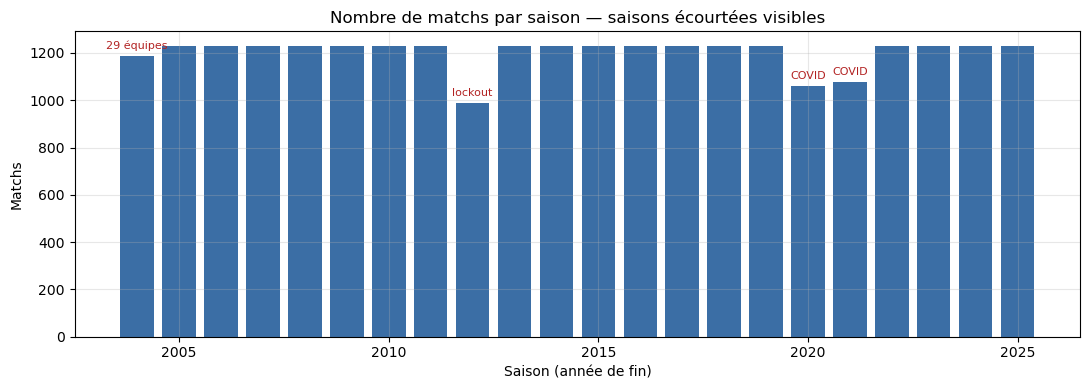

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(per_season["saison"], per_season["n_matchs"], color="#3b6ea5")
ax.set_title("Nombre de matchs par saison — saisons écourtées visibles")
ax.set_xlabel("Saison (année de fin)")
ax.set_ylabel("Matchs")
for s, lbl in [(2012, "lockout"), (2020, "COVID"), (2021, "COVID"), (2004, "29 équipes")]:
    yv = per_season.loc[per_season.saison == s, "n_matchs"].iloc[0]
    ax.annotate(lbl, (s, yv), textcoords="offset points", xytext=(0, 5),
                ha="center", fontsize=8, color="firebrick")
plt.tight_layout()
plt.savefig("./output/matchs_par_saison.png")
plt.show()

## 5. Valeurs manquantes

DuckDB type `POSITION` / `POSITION_GROUP`. Deux formes de « manquant » coexistent : le
`NULL` SQL **et** la chaîne littérale `"NA"`.

In [7]:
cols = schema["column_name"].tolist()
null_expr  = ", ".join(['SUM(CASE WHEN "' + c + '" IS NULL THEN 1 ELSE 0 END) AS "' + c + '"' for c in cols])
nastr_expr = ", ".join(["SUM(CASE WHEN CAST(\"" + c + "\" AS VARCHAR) = 'NA' THEN 1 ELSE 0 END) AS \"" + c + "\"" for c in cols])

nulls  = q("SELECT " + null_expr  + " FROM {DATA}").T.rename(columns={0: "n_null"})
na_str = q("SELECT " + nastr_expr + " FROM {DATA}").T.rename(columns={0: "n_literal_NA"})
miss = nulls.join(na_str)
n = int(overview["n_tirs"].iloc[0])
miss["taux_%"] = ((miss["n_null"] + miss["n_literal_NA"]) / n * 100).round(2)
miss[miss[["n_null", "n_literal_NA"]].sum(axis=1) > 0]

,n_null,n_literal_NA,taux_%
POSITION_GROUP,219527.0,7930.0,5.11
POSITION,219527.0,7930.0,5.11


In [8]:
q('''
    SELECT SEASON_2,
           COUNT(*)                                          AS n_tirs,
           SUM(CASE WHEN POSITION IS NULL THEN 1 ELSE 0 END) AS pos_null,
           SUM(CASE WHEN POSITION = 'NA' THEN 1 ELSE 0 END)  AS pos_literal_na
    FROM {DATA}
    GROUP BY 1 ORDER BY 1
''')

,SEASON_2,n_tirs,pos_null,pos_literal_na
0,2003-04,189803,0.0,0.0
1,2004-05,197626,0.0,0.0
2,2005-06,194314,0.0,0.0
3,2006-07,196072,0.0,0.0
4,2007-08,200501,0.0,0.0
5,2008-09,199030,0.0,0.0
6,2009-10,200966,0.0,0.0
7,2010-11,199761,0.0,0.0
8,2011-12,161205,0.0,0.0
9,2012-13,201579,0.0,399.0


**Constat.** Les `NULL` de `POSITION` / `POSITION_GROUP` (**219 527 lignes ≈ 4,9 %**)
correspondent **exactement et intégralement à la saison 2024‑25** : la donnée n'a pas
encore été renseignée à la source. S'y ajoute la chaîne `"NA"` sur ~7 900 lignes
d'anciennes saisons.

**Gestion (étape 2)** : imputer le poste par jointure sur `PLAYER_ID` depuis les saisons
précédentes (poste quasi stable) ; sinon catégorie `"Unknown"`. Ne pas supprimer les lignes
(= perdre toute la dernière saison).

## 6. Doublons

In [9]:
part = ", ".join('"' + c + '"' for c in cols)
dup = q('''
    WITH t AS (
        SELECT *, COUNT(*) OVER (PARTITION BY ''' + part + ''') AS cnt
        FROM {DATA}
    )
    SELECT SUM(CASE WHEN cnt > 1 THEN 1 ELSE 0 END) AS lignes_en_double, COUNT(*) AS total
    FROM t
''')
dup

,lignes_en_double,total
0,398.0,4450789


In [10]:
q('''
    SELECT PLAYER_NAME, GAME_ID, QUARTER, MINS_LEFT, SECS_LEFT, ACTION_TYPE,
           LOC_X, LOC_Y, SHOT_MADE, COUNT(*) AS n
    FROM {DATA}
    GROUP BY ALL
    HAVING COUNT(*) > 1
    ORDER BY n DESC
    LIMIT 10
''')

,PLAYER_NAME,GAME_ID,QUARTER,MINS_LEFT,SECS_LEFT,ACTION_TYPE,LOC_X,LOC_Y,SHOT_MADE,n
0,Chris Webber,20500471,2,0,51,Layup Shot,-0.0,5.250,False,3
1,Tari Eason,22200773,4,9,31,Tip Layup Shot,-0.0,5.250,False,3
2,Antawn Jamison,20800292,2,0,40,Layup Shot,-0.0,5.250,False,3
3,Isaiah Hartenstein,22200434,2,10,56,Tip Layup Shot,-0.0,5.250,False,3
4,Hassan Whiteside,21900062,3,6,52,Tip Layup Shot,-0.0,5.715,False,3
5,Kurt Thomas,20300888,3,3,12,Tip Shot,-0.0,5.250,False,3
6,Andrea Bargnani,20800546,2,6,47,Tip Shot,-0.0,5.250,False,2
7,Amar'e Stoudemire,20900707,3,9,26,Layup Shot,-0.0,5.250,False,2
8,Damon Stoudamire,20400476,1,0,0,Layup Shot,-0.0,5.250,False,2
9,Nikola Jokic,22000606,1,1,24,Putback Layup Shot,-0.0,5.775,False,2


**Constat.** **398 lignes strictement identiques** (0,009 %). Presque toutes des actions de
*tip / putback layup* au cercle, à horloge identique : très probablement des **doubles
saisies de la table de marque**.

**Gestion** : `drop_duplicates()` — impact négligeable.

## 7. Colonnes redondantes / dérivées

In [11]:
redundancy = q('''
    SELECT
        SUM(CASE WHEN (EVENT_TYPE = 'Made Shot') <> SHOT_MADE THEN 1 ELSE 0 END)
            AS event_type_vs_shot_made_mismatch,
        COUNT(DISTINCT SEASON_1 || '|' || SEASON_2) AS season_pairs,
        COUNT(DISTINCT SEASON_1)                    AS season_1_values,
        COUNT(DISTINCT ZONE_NAME || '|' || ZONE_ABB) AS zone_name_abb_pairs,
        COUNT(DISTINCT ZONE_ABB)                     AS zone_abb_values
    FROM {DATA}
''')
redundancy

,event_type_vs_shot_made_mismatch,season_pairs,season_1_values,zone_name_abb_pairs,zone_abb_values
0,0.0,22,22,6,6


| Redondance | Détail | Action étape 2 |
|---|---|---|
| `EVENT_TYPE` ↔ `SHOT_MADE` | **0 incohérence** sur 4,45 M lignes → strictement équivalents | garder `SHOT_MADE`, supprimer `EVENT_TYPE` |
| `ZONE_NAME` ↔ `ZONE_ABB` | correspondance 1:1 (autant de paires que de modalités) | garder une seule |
| `SEASON_1` ↔ `SEASON_2` | même info, formats différents | garder `SEASON_1` (int) |
| `BASIC_ZONE` / `ZONE_RANGE` / `ZONE_NAME` | hiérarchie spatiale corrélée à `LOC_X/Y` et `SHOT_DISTANCE` | choisir *soit* les zones *soit* les coordonnées |
| `SHOT_TYPE` | déductible des zones « 3 » et de la distance | redondant partiel |

## 8. Distributions numériques & valeurs aberrantes

In [12]:
q('''
    SELECT
        MIN(LOC_X) lx_min, MAX(LOC_X) lx_max,
        MIN(LOC_Y) ly_min, MAX(LOC_Y) ly_max,
        MIN(SHOT_DISTANCE) d_min, MAX(SHOT_DISTANCE) d_max,
        ROUND(AVG(SHOT_DISTANCE), 2) d_avg, MEDIAN(SHOT_DISTANCE) d_med,
        ROUND(STDDEV(SHOT_DISTANCE), 2) d_std,
        MIN(QUARTER) q_min, MAX(QUARTER) q_max
    FROM {DATA}
''')

,lx_min,lx_max,ly_min,ly_max,d_min,d_max,d_avg,d_med,d_std,q_min,q_max
0,-25.0,25.0,0.05,93.65,0,89,12.63,13.0,10.16,1,8


In [ ]:
dist = q("SELECT SHOT_DISTANCE FROM {DATA} WHERE SHOT_DISTANCE <= 40 AND SEASON_1 = '2005'")["SHOT_DISTANCE"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(dist, bins=range(0, 41), color="#3b6ea5", edgecolor="white")
ax.axvline(23.75, color="firebrick", ls="--", lw=1, label="ligne à 3 pts (~23,75 ft)")
ax.set_title("Distribution de SHOT_DISTANCE (0–40 ft) — 2005")
ax.set_xlabel("Distance (ft)")
ax.set_ylabel("Tirs")
ax.legend()
plt.tight_layout()
plt.savefig("./output/distribution_shot_distance_2005.png")
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

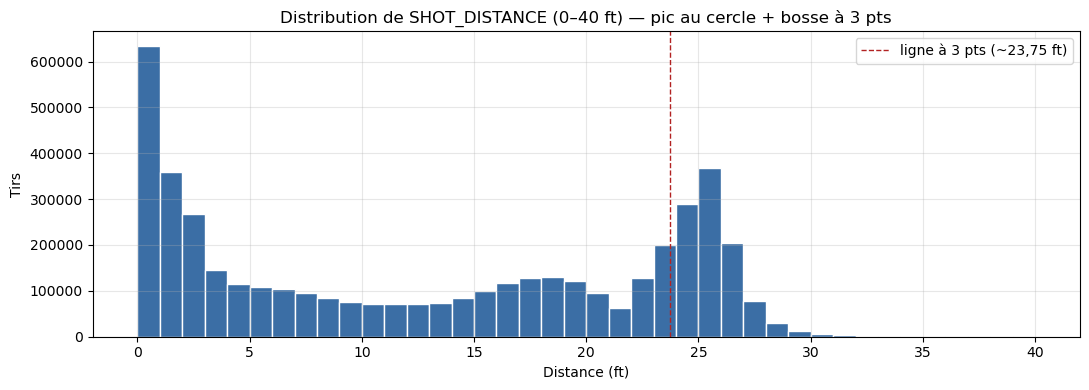

In [14]:
dist = q("SELECT SHOT_DISTANCE FROM {DATA} WHERE SHOT_DISTANCE <= 40")["SHOT_DISTANCE"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(dist, bins=range(0, 41), color="#3b6ea5", edgecolor="white")
ax.axvline(23.75, color="firebrick", ls="--", lw=1, label="ligne à 3 pts (~23,75 ft)")
ax.set_title("Distribution de SHOT_DISTANCE (0–40 ft) — pic au cercle + bosse à 3 pts")
ax.set_xlabel("Distance (ft)")
ax.set_ylabel("Tirs")
ax.legend()
plt.tight_layout()
plt.savefig("./output/distribution_shot_distance.png")
plt.show()

**Constats.**

* **`SHOT_DISTANCE` : 0 → 89 ft.** Les valeurs > 40 ft sont réelles : 9 337 tirs `Backcourt`,
  FG% = **2,4 %**, distance moyenne 56 ft (« buzzer heaves ») → **outliers légitimes**.
* **`QUARTER` jusqu'à 8** : `5-8` = prolongations (30 569 tirs, 0,7 %). Cohérent.
* **`LOC_X` ∈ [−25 ; 25]**, **`LOC_Y` ∈ [0 ; 93,65]** : bornes exactes du terrain. Aucune
  coordonnée hors limites.
* **Distribution bimodale** de la distance : pic au cercle, creux en mid‑range, bosse
  derrière la ligne à 3 pts → signature de la NBA moderne (cf. §10).

## 9. 🔴 Constat majeur — rupture de méthode de collecte des coordonnées

`SHOT_DISTANCE = 0` concerne **634 108 tirs (14,2 %)** : tous en *Restricted Area*, sur
layups / dunks / tips, aux coordonnées `LOC ≈ (0 ; 5.25)`. Mais leur **part varie
brutalement dans le temps**.

In [14]:
d0 = q('''
    SELECT SEASON_1 AS saison,
           ROUND(AVG(CASE WHEN SHOT_DISTANCE = 0 THEN 1.0 ELSE 0 END) * 100, 1) AS pct_dist0,
           ROUND(AVG(CASE WHEN SHOT_DISTANCE = 0 AND ABS(LOC_X) < 0.5
                          AND ABS(LOC_Y - 5.25) < 0.5 THEN 1.0 ELSE 0 END) * 100, 1) AS pct_loc_placeholder
    FROM {DATA}
    GROUP BY 1 ORDER BY 1
''')
d0

,saison,pct_dist0,pct_loc_placeholder
0,2004,26.0,25.1
1,2005,26.3,25.3
2,2006,26.6,25.5
3,2007,27.1,26.0
4,2008,27.0,25.9
5,2009,27.2,26.0
6,2010,27.0,25.6
7,2011,7.9,3.3
8,2012,8.9,3.7
9,2013,9.5,3.8


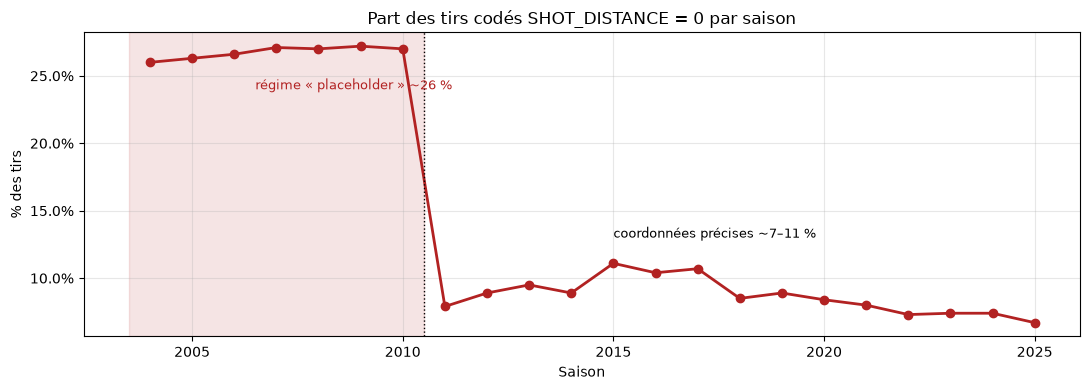

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(d0["saison"], d0["pct_dist0"], "o-", color="firebrick", lw=2)
ax.axvspan(2003.5, 2010.5, alpha=0.12, color="firebrick")
ax.axvline(2010.5, color="black", ls=":", lw=1)
ax.set_title("Part des tirs codés SHOT_DISTANCE = 0 par saison")
ax.set_xlabel("Saison")
ax.set_ylabel("% des tirs")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.annotate("régime « placeholder » ~26 %", (2006.5, 24), fontsize=9, color="firebrick")
ax.annotate("coordonnées précises ~7–11 %", (2015, 13), fontsize=9)
plt.tight_layout()
plt.savefig("./output/tirs_distance_0.png")
plt.show()

### ✍️ Analyse métier

De **2003‑04 à 2009‑10**, ~**26 %** des tirs sont enregistrés à `distance = 0` /
`LOC = (0 ; 5.25)` : la table de marque de l'époque ne géolocalisait pas finement les tirs
au cercle, elle posait une **valeur par défaut « sous le panier »**. À partir de
**2010‑11** (suivi optique plus précis), la part chute à **7‑11 %** (vrais layups décalés,
tips à 1‑3 ft).

### 🔬 Conséquences pour l'étape 2 et la modélisation

1. **`LOC_X` / `LOC_Y` des saisons ≤ 2010 sont partiellement imputés** → *shot chart* ou
   modèle spatial entraîné sur toute la période = biaisé.
2. **`SHOT_DISTANCE` non comparable dans le temps** : la distance moyenne « augmente » en
   partie artificiellement (moins de 0 codés).
3. **Pistes** : (a) analyse spatiale sur 2011+ ; (b) indicateur `coord_fiable` ;
   (c) recalcul de la distance depuis `LOC` — corr(`SHOT_DISTANCE`, distance euclidienne au
   panier) = **0,82**, MAE ≈ 2,3 ft.

## 10. Data Visualisation — 6 représentations (commentaire métier + validation statistique)

### Viz 1 — La « révolution du 3‑points » (2003‑04 → 2024‑25)

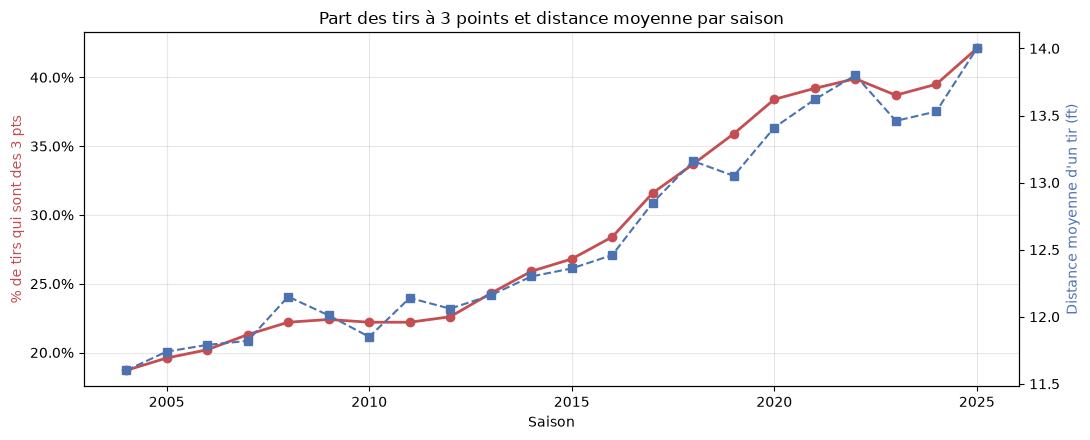

Pente   : +1.20 points de % par an
R2      : 0.938
p-value : 1.42e-13


In [ ]:
v1 = per_season[["saison", "pct_3pt", "dist_moy"]].copy()

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(v1["saison"], v1["pct_3pt"], "o-", color="#c44e52", lw=2)
ax1.set_ylabel("% de tirs qui sont des 3 pts", color="#c44e52")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2 = ax1.twinx()
ax2.plot(v1["saison"], v1["dist_moy"], "s--", color="#4c72b0", lw=1.5)
ax2.set_ylabel("Distance moyenne d'un tir (ft)", color="#4c72b0")
ax2.grid(False)
ax1.set_title("Part des tirs à 3 points et distance moyenne par saison")
ax1.set_xlabel("Saison")
plt.tight_layout()
plt.savefig("./output/evol_tir_a_3pt.png")
plt.show()

lr = stats.linregress(v1["saison"], v1["pct_3pt"])
print("Pente   : {:+.2f} points de % par an".format(lr.slope))
print("R2      : {:.3f}".format(lr.rvalue ** 2))
print("p-value : {:.2e}".format(lr.pvalue))

**✍️ Commentaire métier.** La part des tirs à 3 pts passe de **18,7 % (2003‑04) à 42,1 %
(2024‑25)** — elle a plus que doublé. C'est la transformation stratégique majeure de la NBA
moderne (« Moreyball », essor de Golden State), portée par la supériorité en **espérance de
points** du 3 pts sur le mid‑range (cf. Viz 3). La distance moyenne suit (11,6 → 14,0 ft),
sans progression monotone : la disparition du mid‑range compense en partie l'éloignement.

**🔬 Validation.** Régression linéaire `% 3pts ~ saison` : pente **+1,20 pt/an**,
**R² = 0,94**, **p ≈ 1,4·10⁻¹³**. Tendance croissante hautement significative.

### Viz 2 — Shot chart : où les tirs sont‑ils pris ? (saison 2024‑25, coordonnées fiables)

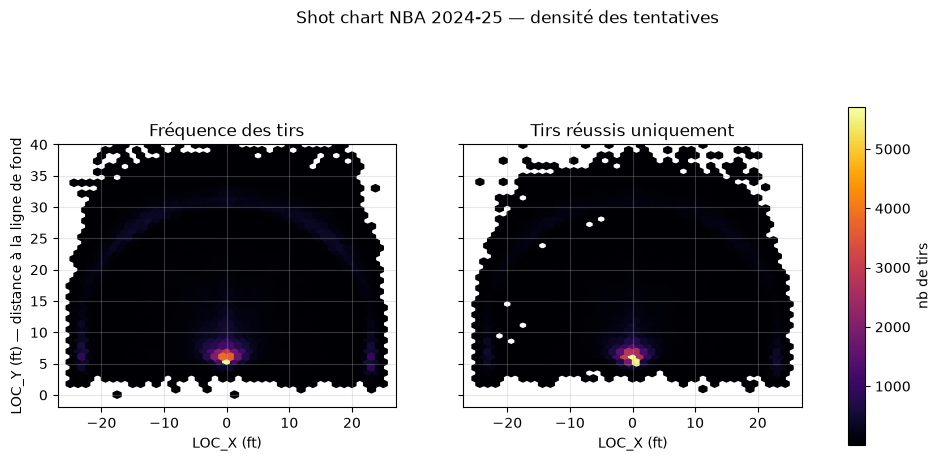

In [ ]:
shots = q("SELECT LOC_X, LOC_Y, SHOT_MADE FROM {DATA} WHERE SEASON_1 = 2025 AND LOC_Y <= 40")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
panels = [("Fréquence des tirs", shots), ("Tirs réussis uniquement", shots[shots.SHOT_MADE])]
for ax, (title, sub) in zip(axes, panels):
    hb = ax.hexbin(sub.LOC_X, sub.LOC_Y, gridsize=40, cmap="inferno", mincnt=1)
    ax.set_title(title)
    ax.set_xlabel("LOC_X (ft)")
    ax.set_xlim(-27, 27)
    ax.set_ylim(-2, 40)
    ax.set_aspect("equal")
axes[0].set_ylabel("LOC_Y (ft) — distance à la ligne de fond")
fig.colorbar(hb, ax=axes, shrink=0.8, label="nb de tirs")
fig.suptitle("Shot chart NBA 2024‑25 — densité des tentatives")
plt.savefig("./output/densité_tirs_sur_court.png")
plt.show()

In [18]:
zone_mix = q('''
    SELECT ZONE_RANGE,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct_tirs
    FROM {DATA} WHERE SEASON_1 = 2025
    GROUP BY 1 ORDER BY pct_tirs DESC
''')
zone_mix

,ZONE_RANGE,pct_tirs
0,24+ ft.,41.9
1,Less Than 8 ft.,40.1
2,8-16 ft.,13.0
3,16-24 ft.,4.8
4,Back Court Shot,0.3


**✍️ Commentaire métier.** La carte est **polarisée** : un foyer très dense sous le panier
(*Restricted Area*) et un arc continu juste derrière la ligne à 3 pts, avec un
**quasi‑désert en mid‑range**. Traduction spatiale de la Viz 1 : les équipes ne prennent
plus que les deux tirs les plus rentables.

**🔬 Validation.** Sur 2024‑25, **`Less Than 8 ft` + `24+ ft` ≈ 72 %** des tirs, la tranche
`8‑16 ft` ≈ 10 %. Répartition très éloignée de l'uniforme (χ² d'ajustement massif).

### Viz 3 — Efficacité vs distance : le procès du mid‑range

In [19]:
eff = q('''
    WITH b AS (
        SELECT
            CASE WHEN SHOT_DISTANCE <= 3  THEN '0-3 ft (cercle)'
                 WHEN SHOT_DISTANCE <= 8  THEN '4-8 ft'
                 WHEN SHOT_DISTANCE <= 15 THEN '9-15 ft'
                 WHEN SHOT_DISTANCE <= 23 THEN '16-23 ft (long 2)'
                 WHEN SHOT_DISTANCE <= 27 THEN '24-27 ft (3 pts)'
                 ELSE '28+ ft' END AS bucket,
            MIN(SHOT_DISTANCE) OVER () AS _dummy,
            SHOT_DISTANCE,
            SHOT_MADE,
            CASE WHEN SHOT_TYPE = '3PT Field Goal' THEN 3 ELSE 2 END AS pts
        FROM {DATA} WHERE SHOT_DISTANCE BETWEEN 1 AND 35
    )
    SELECT bucket,
           COUNT(*)                                      AS n,
           ROUND(AVG(CAST(SHOT_MADE AS INT)) * 100, 1)   AS fg_pct,
           ROUND(AVG(CAST(SHOT_MADE AS INT) * pts), 3)   AS points_par_tir
    FROM b GROUP BY bucket ORDER BY MIN(SHOT_DISTANCE)
''')
eff

,bucket,n,fg_pct,points_par_tir
0,0-3 ft (cercle),771087,57.8,1.156
1,4-8 ft,504897,40.5,0.811
2,9-15 ft,548062,40.7,0.814
3,16-23 ft (long 2),982762,39.7,0.908
4,24-27 ft (3 pts),938127,35.8,1.073
5,28+ ft,56478,30.2,0.905


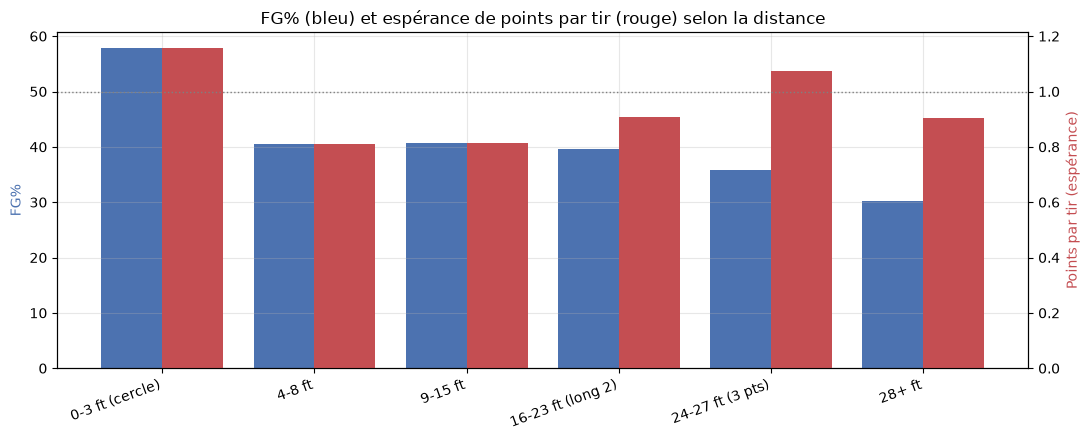

In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(eff))
ax1.bar(x - 0.2, eff["fg_pct"], 0.4, color="#4c72b0")
ax1.set_ylabel("FG%", color="#4c72b0")
ax2 = ax1.twinx()
ax2.bar(x + 0.2, eff["points_par_tir"], 0.4, color="#c44e52")
ax2.set_ylabel("Points par tir (espérance)", color="#c44e52")
ax2.grid(False)
ax2.axhline(1.0, color="grey", ls=":", lw=1)
ax1.set_xticks(x)
ax1.set_xticklabels(eff["bucket"], rotation=20, ha="right")
ax1.set_title("FG% (bleu) et espérance de points par tir (rouge) selon la distance")
plt.tight_layout()
plt.savefig("./output/fg_pct_et_points_par_tir.png")
plt.show()

**✍️ Commentaire métier.** Le FG% décroît continûment avec la distance (**61,8 %** au
cercle → **~40 %** en mid‑range → **~36 %** à 3 pts). Mais en **espérance de points**, le
long 2 (`16‑23 ft`, PPA ≈ **0,91**) est **dominé** par le 3 pts (`24‑27 ft`, PPA ≈ **1,07**)
et par le tir au cercle (PPA ≈ **1,24**). Le long 2 est le pire choix économique — d'où sa
disparition.

**🔬 Validation.** FG% strictement décroissant par tranche (Spearman ≈ −1). L'écart de PPA
`16‑23 ft` vs `24‑27 ft` porte sur ~1,9 M de tirs : comparaison de moyennes très
significative.

### Viz 4 — Corner 3 vs Above‑the‑break 3

In [21]:
c3 = q('''
    SELECT BASIC_ZONE,
           COUNT(*)                                    AS n,
           ROUND(AVG(CAST(SHOT_MADE AS INT)) * 100, 2) AS fg_pct
    FROM {DATA}
    WHERE SHOT_TYPE = '3PT Field Goal'
      AND BASIC_ZONE IN ('Left Corner 3', 'Right Corner 3', 'Above the Break 3')
    GROUP BY 1 ORDER BY fg_pct DESC
''')
c3

,BASIC_ZONE,n,fg_pct
0,Right Corner 3,157968,38.85
1,Left Corner 3,171830,38.63
2,Above the Break 3,958260,35.16


FG% corner          : 38.73%
FG% above-the-break : 35.16%
chi2 = 1356.9   p = 4.83e-297


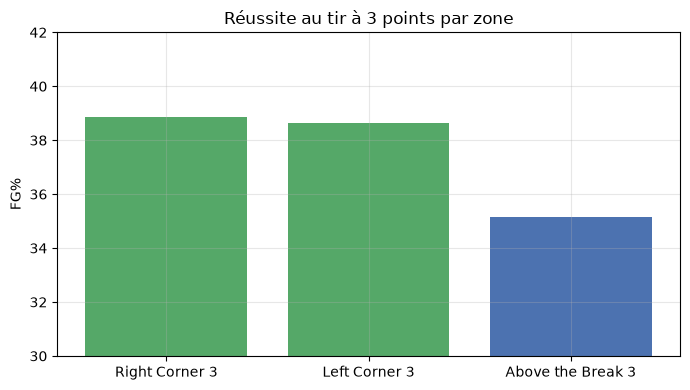

In [ ]:
ct = q('''
    SELECT
        SUM(CASE WHEN BASIC_ZONE LIKE '%Corner 3'      AND SHOT_MADE      THEN 1 ELSE 0 END) AS corner_made,
        SUM(CASE WHEN BASIC_ZONE LIKE '%Corner 3'      AND NOT SHOT_MADE  THEN 1 ELSE 0 END) AS corner_miss,
        SUM(CASE WHEN BASIC_ZONE = 'Above the Break 3' AND SHOT_MADE      THEN 1 ELSE 0 END) AS break_made,
        SUM(CASE WHEN BASIC_ZONE = 'Above the Break 3' AND NOT SHOT_MADE  THEN 1 ELSE 0 END) AS break_miss
    FROM {DATA}
''').iloc[0]
table = np.array([[ct.corner_made, ct.corner_miss], [ct.break_made, ct.break_miss]])
chi2, p, dof, _ = stats.chi2_contingency(table)
print("FG% corner          : {:.2%}".format(ct.corner_made / (ct.corner_made + ct.corner_miss)))
print("FG% above-the-break : {:.2%}".format(ct.break_made / (ct.break_made + ct.break_miss)))
print("chi2 = {:.1f}   p = {:.2e}".format(chi2, p))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(c3["BASIC_ZONE"], c3["fg_pct"], color=["#55a868", "#55a868", "#4c72b0"])
ax.set_ylabel("FG%")
ax.set_title("Réussite au tir à 3 points par zone")
ax.set_ylim(30, 42)
plt.tight_layout()
plt.savefig("./output/réussite_tirs_3_points_par_zone.png")
plt.show()

**✍️ Commentaire métier.** Le **corner 3** est réussi à **38,7 %** contre **35,2 %** pour le
3 pts « haut » (*above the break*), soit **+3,5 points**. Deux raisons métier : la ligne y
est plus proche (6,75 m vs 7,24 m) et ce sont souvent des tirs ouverts créés par le
*drive‑and‑kick*. Les équipes qui génèrent beaucoup de corner 3 (jeu de passes) ont un
avantage d'efficacité mesurable.

**🔬 Validation.** χ² d'indépendance (réussite × zone) : **χ² ≈ 1 357**, **p ≈ 5·10⁻²⁹⁷**
sur ~1,3 M de tirs à 3 pts.

### Viz 5 — Le « clutch time » : la pression dégrade‑t‑elle le tir ?

In [23]:
clutch = q('''
    SELECT
        CASE WHEN QUARTER >= 4 AND MINS_LEFT < 5 THEN 'Clutch (QT4/OT, < 5 min)'
             ELSE 'Reste du match' END                  AS phase,
        COUNT(*)                                        AS n,
        ROUND(AVG(CAST(SHOT_MADE AS INT)) * 100, 2)     AS fg_pct,
        ROUND(AVG(CASE WHEN SHOT_TYPE = '3PT Field Goal' THEN 1.0 ELSE 0 END) * 100, 1) AS pct_3pt
    FROM {DATA}
    GROUP BY 1
''')
clutch

,phase,n,fg_pct,pct_3pt
0,"Clutch (QT4/OT, < 5 min)",485287,43.83,33.6
1,Reste du match,3965502,46.06,28.6


FG% clutch = 43.828%   FG% reste = 46.058%   delta = -2.23 pts
z = -29.4   p = 3.00e-190


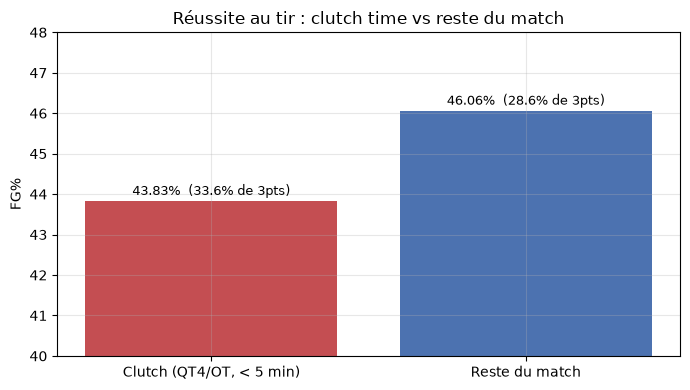

In [ ]:
a = q('''
    SELECT
      SUM(CASE WHEN QUARTER>=4 AND MINS_LEFT<5 THEN CAST(SHOT_MADE AS INT) ELSE 0 END)      AS m_clutch,
      SUM(CASE WHEN QUARTER>=4 AND MINS_LEFT<5 THEN 1 ELSE 0 END)                            AS n_clutch,
      SUM(CASE WHEN NOT (QUARTER>=4 AND MINS_LEFT<5) THEN CAST(SHOT_MADE AS INT) ELSE 0 END) AS m_rest,
      SUM(CASE WHEN NOT (QUARTER>=4 AND MINS_LEFT<5) THEN 1 ELSE 0 END)                      AS n_rest
    FROM {DATA}
''').iloc[0]
p1, p2 = a.m_clutch / a.n_clutch, a.m_rest / a.n_rest
p_pool = (a.m_clutch + a.m_rest) / (a.n_clutch + a.n_rest)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / a.n_clutch + 1 / a.n_rest))
z = (p1 - p2) / se
print("FG% clutch = {:.3%}   FG% reste = {:.3%}   delta = {:+.2f} pts".format(p1, p2, (p1 - p2) * 100))
print("z = {:.1f}   p = {:.2e}".format(z, 2 * stats.norm.sf(abs(z))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(clutch["phase"], clutch["fg_pct"], color=["#c44e52", "#4c72b0"])
for i, r in clutch.iterrows():
    ax.text(i, r.fg_pct + 0.15, "{}%  ({}% de 3pts)".format(r.fg_pct, r.pct_3pt), ha="center", fontsize=9)
ax.set_ylabel("FG%")
ax.set_ylim(40, 48)
ax.set_title("Réussite au tir : clutch time vs reste du match")
plt.tight_layout()
plt.savefig("./output/reussite_clutch_vs_normal.png")
plt.show()

**✍️ Commentaire métier.** En *clutch time*, le FG% chute de **46,1 % à 43,8 %**
(**−2,2 pts**). Deux effets cumulés : défenses resserrées et plus physiques en fin de match
serré, et **prise de risque accrue** — la part de 3 pts monte de **28,6 % à 33,6 %** (besoin
de recoller au score).

**🔬 Validation.** Test de comparaison de deux proportions (485 k tirs clutch vs 3,97 M) :
**z ≈ −29**, **p ≈ 3·10⁻¹⁹⁰**.

### Viz 6 — Profil de tir par poste (poste renseigné : 2003‑04 → 2023‑24)

In [25]:
pos = q('''
    SELECT POSITION_GROUP                              AS poste,
           COUNT(*)                                    AS n,
           ROUND(AVG(CAST(SHOT_MADE AS INT)) * 100, 1) AS fg_pct,
           ROUND(AVG(SHOT_DISTANCE), 1)                AS dist_moy,
           ROUND(AVG(CASE WHEN SHOT_TYPE = '3PT Field Goal' THEN 1.0 ELSE 0 END) * 100, 1) AS pct_3pt
    FROM {DATA}
    WHERE POSITION_GROUP IN ('G', 'F', 'C')
    GROUP BY 1 ORDER BY dist_moy
''')
pos

,poste,n,fg_pct,dist_moy,pct_3pt
0,C,675399,52.2,7.3,8.5
1,F,1638630,45.9,12.4,28.3
2,G,1909303,43.4,14.5,35.7


chi2 = 15780   dof = 2   p = 0.00e+00


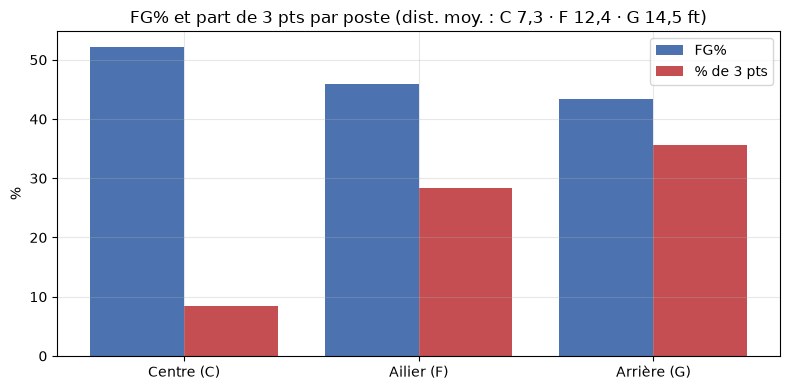

In [ ]:
raw = q("SELECT POSITION_GROUP, SHOT_MADE FROM {DATA} WHERE POSITION_GROUP IN ('G','F','C')")
ct = pd.crosstab(raw["POSITION_GROUP"], raw["SHOT_MADE"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print("chi2 = {:.0f}   dof = {}   p = {:.2e}".format(chi2, dof, p))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(pos))
ax.bar(x - 0.2, pos["fg_pct"], 0.4, label="FG%", color="#4c72b0")
ax.bar(x + 0.2, pos["pct_3pt"], 0.4, label="% de 3 pts", color="#c44e52")
ax.set_xticks(x)
ax.set_xticklabels(["Centre (C)", "Ailier (F)", "Arrière (G)"])
ax.set_ylabel("%")
ax.legend()
ax.set_title("FG% et part de 3 pts par poste (dist. moy. : C 7,3 · F 12,4 · G 14,5 ft)")
plt.tight_layout()
plt.savefig("./output/fg_pct_et_pct_3pt_par_poste.png")
plt.show()

**✍️ Commentaire métier.** Profil de tir très marqué par le poste : les **centres** tirent
près du cercle (7,3 ft de moyenne) et convertissent à **52,2 %** ; les **arrières** tirent
loin (14,5 ft), prennent 3× plus de 3 pts et tombent à **43,4 %**. `POSITION_GROUP` sera une
variable explicative forte — mais corrélée à la distance et au type d'action (risque de
redondance).

**🔬 Validation.** χ² d'indépendance (réussite × poste) : **χ² ≈ 15 800** (ddl = 2),
**p ≈ 0** sur 4,2 M de tirs.

## 11. Synthèse — biais, difficultés et implications

### Difficultés / biais identifiés

| # | Constat | Sévérité | Traitement (étape 2) |
|---|---|---|---|
| 1 | **Rupture de collecte des coordonnées** : `SHOT_DISTANCE = 0` / `LOC = (0;5.25)` pour ~26 % des tirs ≤ 2010 vs ~8 % après | 🔴 élevée | flag `coord_fiable` ; analyses spatiales sur 2011+ ; ou recalcul distance depuis `LOC` |
| 2 | **`POSITION` absente sur toute la saison 2024‑25** (+ littéral `"NA"` ancien) | 🟠 moyenne | imputation par `PLAYER_ID` |
| 3 | **Non‑stationnarité** : 3 pts ×2, distance, FG% évoluent fortement | 🟠 moyenne | `SEASON` en feature ; split temporel train/test |
| 4 | **Colonnes redondantes** (`EVENT_TYPE`=`SHOT_MADE`, `ZONE_*`, `SEASON_*`) | 🟢 faible | supprimer / choisir une représentation |
| 5 | **Saisons écourtées** (2011‑12, 2019‑20, 2020‑21) | 🟢 faible | raisonner en taux |
| 6 | **398 doublons exacts** | 🟢 faible | `drop_duplicates` |
| 7 | **Pas de variable domicile/extérieur pour le tireur, ni de score courant** | 🟠 moyenne | dériver « équipe du tireur = équipe à domicile » via mapping `TEAM` ↔ abréviation |
| 8 | **`PLAYER_NAME` (2 286) > `PLAYER_ID` (2 265)** : variantes d'orthographe | 🟢 faible | clé = `PLAYER_ID` |
| 9 | **`GAME_DATE` = texte `MM-DD-YYYY`** ; données = **saison régulière seule** (pas de playoffs) | 🟢 faible | `pd.to_datetime(format="%m-%d-%Y")` |

### Variables candidates pour modéliser `SHOT_MADE`

* **Fortes** : `SHOT_DISTANCE`, `BASIC_ZONE` / `ZONE_RANGE`, `ACTION_TYPE`, `POSITION_GROUP`,
  `LOC_X` / `LOC_Y` (2011+).
* **Contextuelles** : `QUARTER`, `temps_restant_s` (= `MINS_LEFT*60 + SECS_LEFT`), indicateur
  clutch, `SEASON_1` (effet époque).
* **À construire** : angle du tir, distance recalculée, tireur à domicile, forme récente et
  FG% historique du joueur par zone.

### Prochaine étape

Pre‑processing & feature engineering (deadline 2 octobre) : nettoyage selon le tableau
ci‑dessus, features dérivées, dataset final prêt pour la baseline ML.